In [1]:
# Restart kernel and reload modules to pick up config changes
%load_ext autoreload
%autoreload 2

# ODIR-5K Dataset Exploration

This notebook provides a comprehensive exploration of the Ocular Disease Intelligent Recognition (ODIR) dataset.

## Dataset Information

- **Patients**: 5,000
- **Images**: ~10,000 (left and right eye fundus photographs)
- **Disease Categories**: 8 (N, D, G, C, A, H, M, O)
- **Multi-label**: Yes - patients can have multiple diseases

## 1. Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import sys

# Add parent directory to path to import modules
parent_dir = Path.cwd().parent
sys.path.insert(0, str(parent_dir))

# Import from src directory
from src.utils import (
    load_dataset, 
    get_disease_statistics,
    plot_disease_distribution,
    analyze_multilabel,
    plot_age_gender_distribution,
    visualize_samples,
    create_correlation_matrix
)
from config import DISEASE_LABELS, LABEL_COLUMNS, DISEASE_COLORS

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("✓ Imports successful")

✓ Imports successful


## 2. Load Dataset

In [3]:
# Load the dataset (Excel file)
from pathlib import Path

# Adjust path for notebook location
data_file = Path("../ODIR-5K/data.xlsx")  # Go up one level from notebooks/
df = pd.read_excel(data_file)

print(f"\nDataset shape: {df.shape}")
print(f"Number of patients: {len(df)}")
print(f"\nColumn names:")
print(df.columns.tolist())


Dataset shape: (3500, 15)
Number of patients: 3500

Column names:
['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']


## 3. Basic Data Inspection

In [4]:
# Display first few rows
print("First 5 rows:")
df.head()

First 5 rows:


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1


In [5]:
# Data types and missing values
print("Data types and missing values:")
print(df.info())

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         3500 non-null   int64 
 1   Patient Age                3500 non-null   int64 
 2   Patient Sex                3500 non-null   object
 3   Left-Fundus                3500 non-null   object
 4   Right-Fundus               3500 non-null   object
 5   Left-Diagnostic Keywords   3500 non-null   object
 6   Right-Diagnostic Keywords  3500 non-null   object
 7   N                          3500 non-null   int64 
 8   D                          3500 non-null   int64 
 9   G                          3500 non-null   int64 
 10  C                          3500 non-null   int64 
 11  A                          3500 non-null   int64 
 12  H                          3500 non-null   int64 
 13  M                          3500 

In [6]:
# Statistical summary
print("Statistical summary:")
df.describe()

Statistical summary:


,ID,Patient Age,N,D,G,C,A,H,M,O
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,2218.233143,57.854000,0.325714,0.322286,0.061429,0.060571,0.046857,0.029429,0.049714,0.279714
std,1415.437872,11.724064,0.468708,0.467419,0.240149,0.238577,0.211363,0.169029,0.217385,0.448923
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,876.750000,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2372.500000,59.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3247.250000,66.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,4784.000000,91.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Disease Distribution Analysis

In [7]:
# Get disease statistics
disease_stats = get_disease_statistics(df)
print("Disease Statistics:")
print(disease_stats.to_string(index=False))

Disease Statistics:
Disease Code                     Disease Name  Count Percentage
           N                           Normal   1140     32.57%
           D                         Diabetes   1128     32.23%
           G                         Glaucoma    215      6.14%
           C                         Cataract    212      6.06%
           A Age-related Macular Degeneration    164      4.69%
           M              Pathological Myopia    174      4.97%
           O     Other diseases/abnormalities    979     27.97%


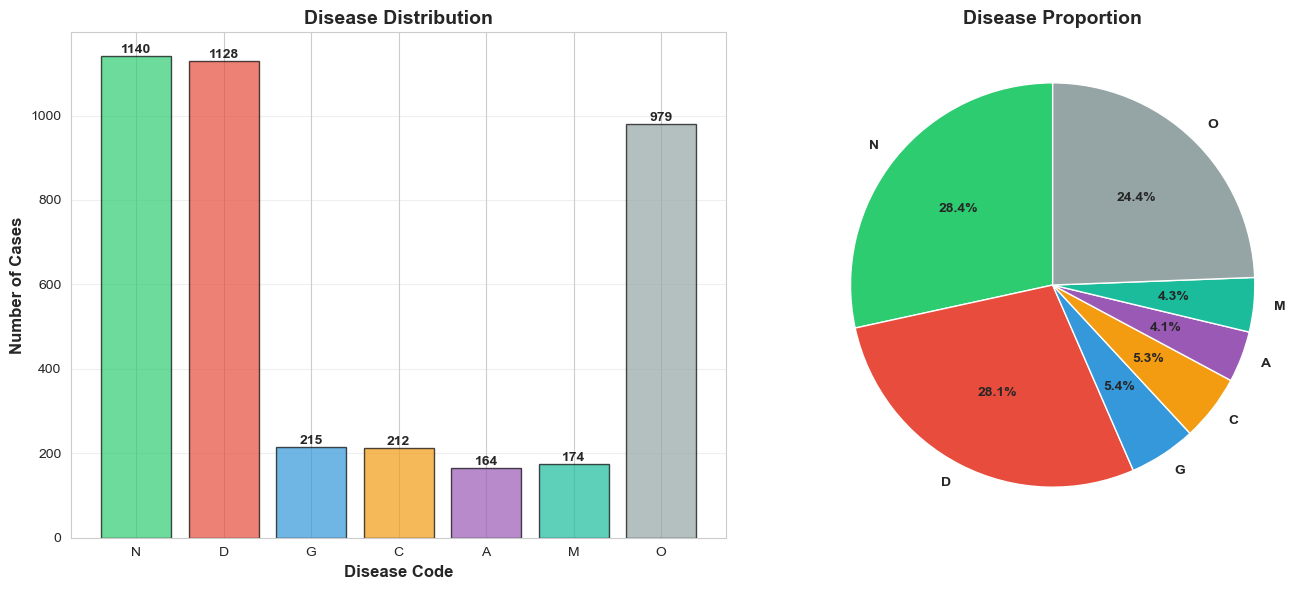

In [8]:
# Visualize disease distribution
stats = plot_disease_distribution(df, figsize=(14, 6))

## 5. Multi-Label Analysis

In [9]:
# Analyze multi-label distribution
multilabel_analysis = analyze_multilabel(df)

Multi-label Analysis:
  Single disease: 2941 patients
  Multiple diseases: 523 patients
  No disease labeled: 36 patients
  Max diseases per patient: 3
  Avg diseases per patient: 1.15


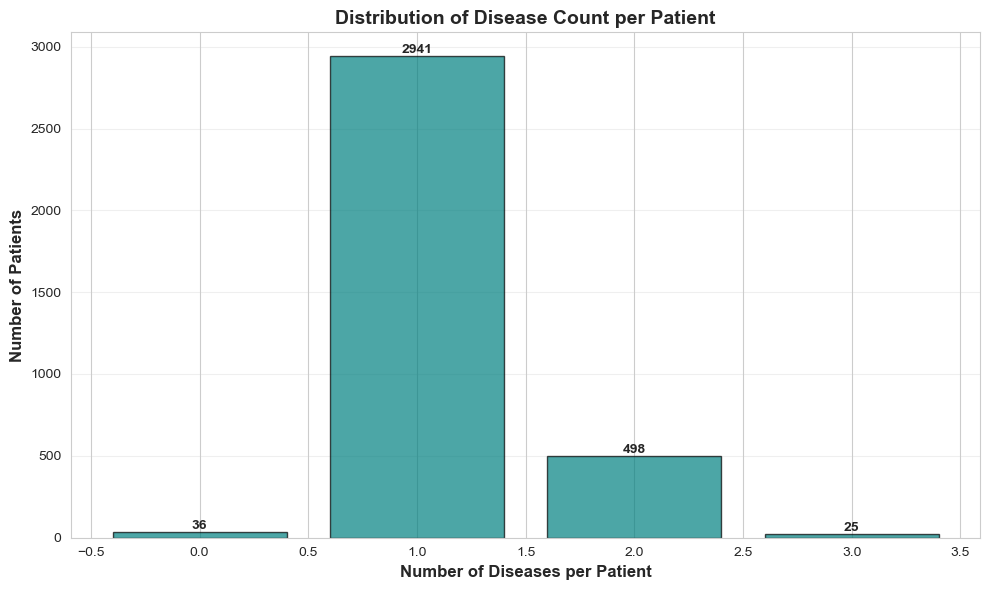

In [10]:
# Visualize number of diseases per patient
disease_counts = df[LABEL_COLUMNS].sum(axis=1)

plt.figure(figsize=(10, 6))
count_dist = disease_counts.value_counts().sort_index()
plt.bar(count_dist.index, count_dist.values, color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Number of Diseases per Patient', fontsize=12, fontweight='bold')
plt.ylabel('Number of Patients', fontsize=12, fontweight='bold')
plt.title('Distribution of Disease Count per Patient', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (count, freq) in enumerate(zip(count_dist.index, count_dist.values)):
    plt.text(count, freq, str(freq), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Disease Co-occurrence Analysis

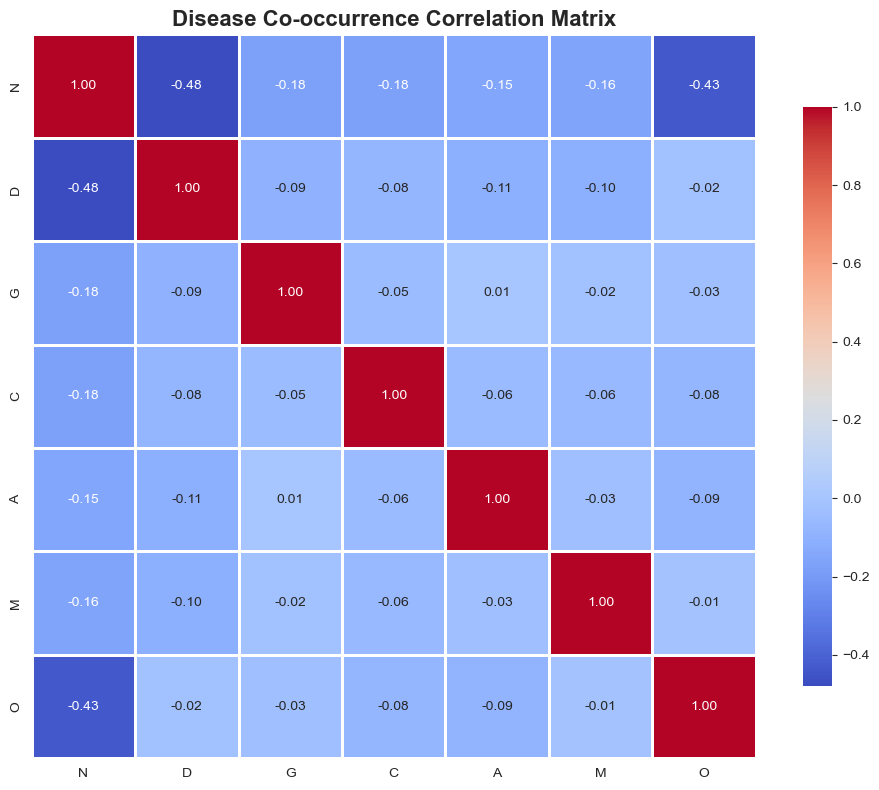

In [11]:
# Create correlation matrix for disease co-occurrence
corr_matrix = create_correlation_matrix(df, figsize=(10, 8))

In [12]:
# Find most common disease combinations
print("Most common disease combinations:")

# Create combination labels
df_labels = df[LABEL_COLUMNS].copy()
df_labels['combination'] = df_labels.apply(
    lambda row: '+'.join([label for label in LABEL_COLUMNS if row[label] == 1]), 
    axis=1
)

combination_counts = df_labels['combination'].value_counts().head(10)
print(combination_counts)

Most common disease combinations:
combination
N      1140
D       741
O       559
D+O     283
C       148
G       125
A       121
M       107
M+O      40
G+O      38
Name: count, dtype: int64


## 7. Patient Demographics

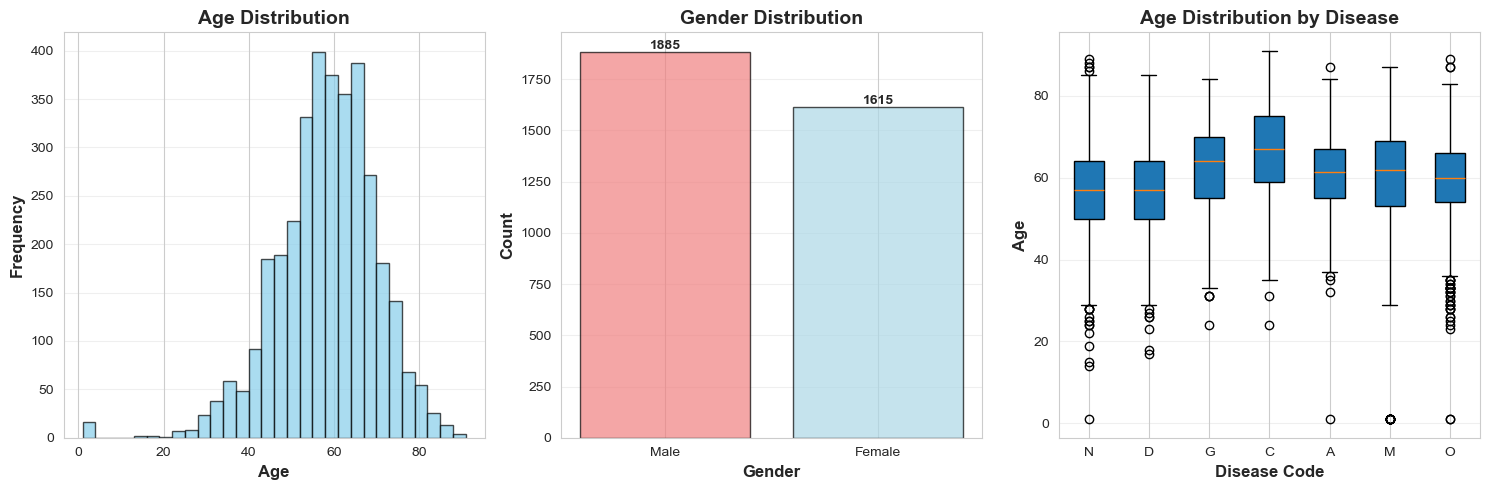

In [13]:
# Plot age and gender distribution
plot_age_gender_distribution(df, figsize=(15, 5))

In [14]:
# Age statistics by disease
print("Age statistics by disease:\n")
for label in LABEL_COLUMNS:
    if label in df.columns and 'Patient Age' in df.columns:
        ages = df[df[label] == 1]['Patient Age'].dropna()
        if len(ages) > 0:
            print(f"{label} ({DISEASE_LABELS[label]}):")
            print(f"  Mean age: {ages.mean():.1f}")
            print(f"  Median age: {ages.median():.1f}")
            print(f"  Age range: {ages.min():.0f} - {ages.max():.0f}")
            print()

Age statistics by disease:

N (Normal):
  Mean age: 56.6
  Median age: 57.0
  Age range: 1 - 89

D (Diabetes):
  Mean age: 56.5
  Median age: 57.0
  Age range: 17 - 85

G (Glaucoma):
  Mean age: 62.3
  Median age: 64.0
  Age range: 24 - 84

C (Cataract):
  Mean age: 66.4
  Median age: 67.0
  Age range: 24 - 91

A (Age-related Macular Degeneration):
  Mean age: 60.9
  Median age: 61.5
  Age range: 1 - 87

M (Pathological Myopia):
  Mean age: 57.2
  Median age: 62.0
  Age range: 1 - 87

O (Other diseases/abnormalities):
  Mean age: 59.1
  Median age: 60.0
  Age range: 1 - 89



## 8. Sample Image Visualization

Visualizing random samples...


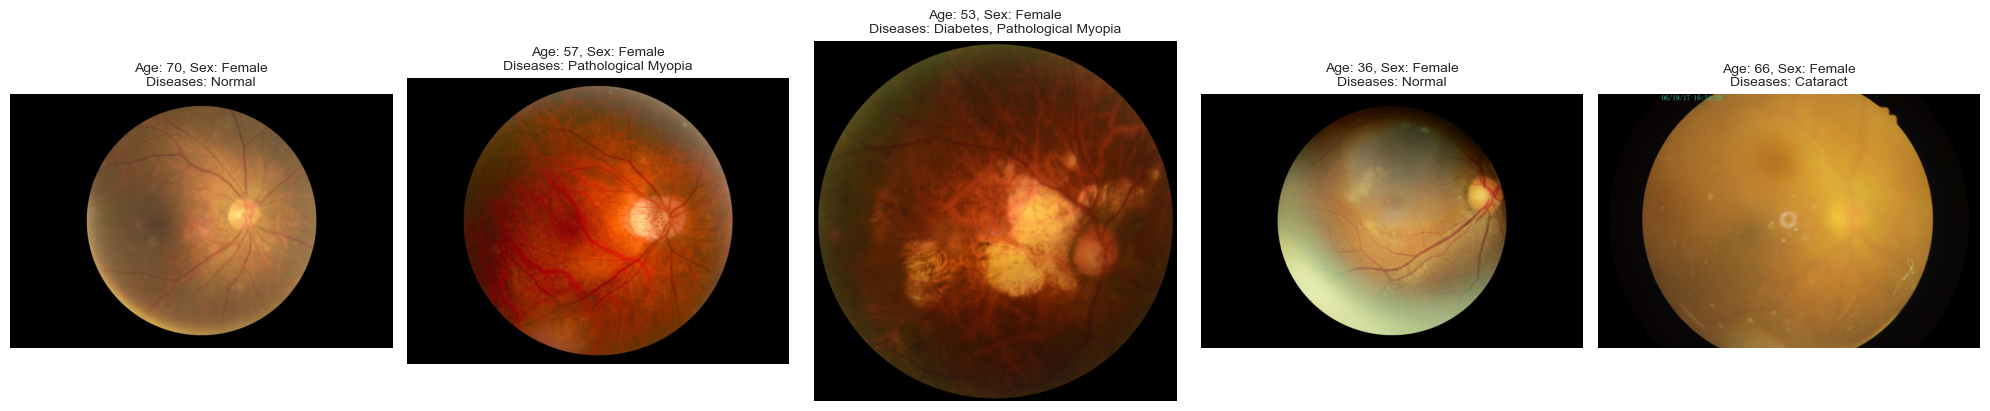

In [15]:
# Visualize random samples
print("Visualizing random samples...")
visualize_samples(df, n_samples=5, image_column='Right-Fundus', show_labels=True)

In [16]:
# Debug: Check image paths
from config import DATA_DIR, TRAIN_IMAGE_DIR

print(f"DATA_DIR: {DATA_DIR}")
print(f"DATA_DIR exists: {DATA_DIR.exists()}")
print(f"TRAIN_IMAGE_DIR: {TRAIN_IMAGE_DIR}")
print(f"TRAIN_IMAGE_DIR exists: {TRAIN_IMAGE_DIR.exists()}")

# Check if we can find a sample image
if 'Right-Fundus' in df.columns:
    sample_image = df['Right-Fundus'].iloc[0]
    print(f"\nSample image filename: {sample_image}")
    
    # Check possible paths
    possible_paths = [
        DATA_DIR / sample_image,
        TRAIN_IMAGE_DIR / sample_image,
        Path("..") / "ODIR-5K" / "Training Images" / sample_image,
    ]
    
    for path in possible_paths:
        print(f"  {path}: {'EXISTS' if path.exists() else 'NOT FOUND'}")

DATA_DIR: /Users/fdb/VSCode/ODR/ODIR-5K
DATA_DIR exists: True
TRAIN_IMAGE_DIR: /Users/fdb/VSCode/ODR/ODIR-5K/Training Images
TRAIN_IMAGE_DIR exists: True

Sample image filename: 0_right.jpg
  /Users/fdb/VSCode/ODR/ODIR-5K/0_right.jpg: NOT FOUND
  /Users/fdb/VSCode/ODR/ODIR-5K/Training Images/0_right.jpg: EXISTS
  ../ODIR-5K/Training Images/0_right.jpg: EXISTS


In [17]:
# Reload utils module to pick up the fix
import importlib
from src import utils
importlib.reload(utils)
from src.utils import visualize_samples

print("✓ Utils module reloaded with image path fix")

✓ Utils module reloaded with image path fix


Visualizing samples by disease category...


Normal (N):


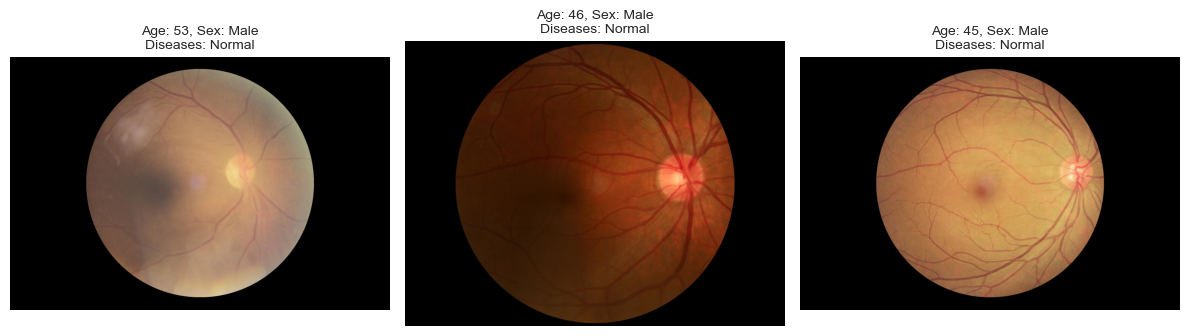


Diabetes (D):


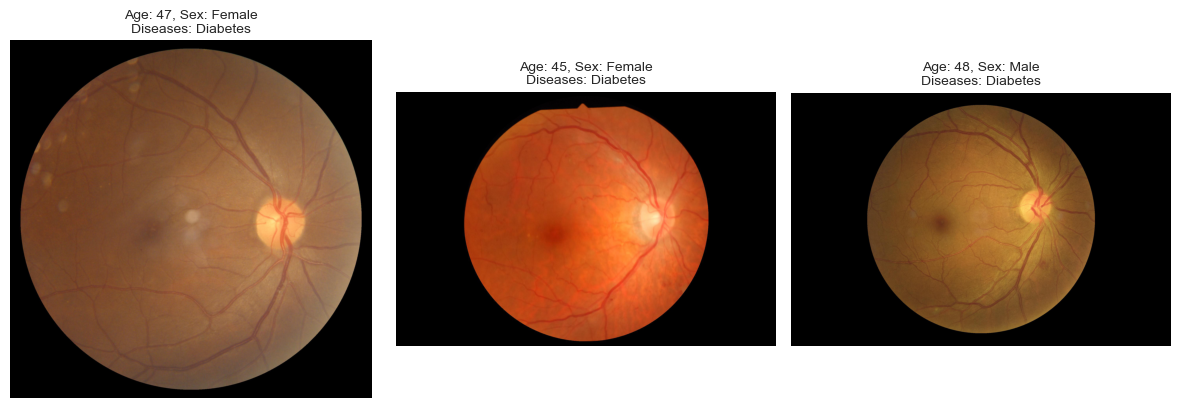


Glaucoma (G):


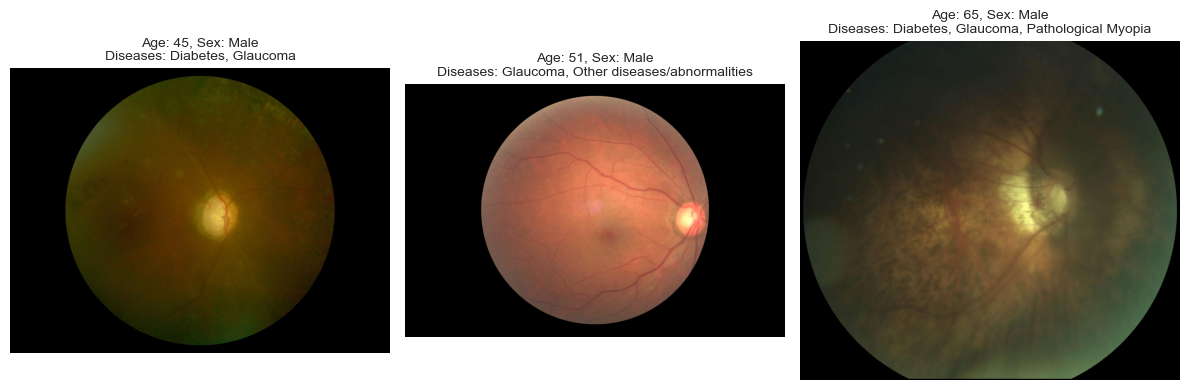


Cataract (C):


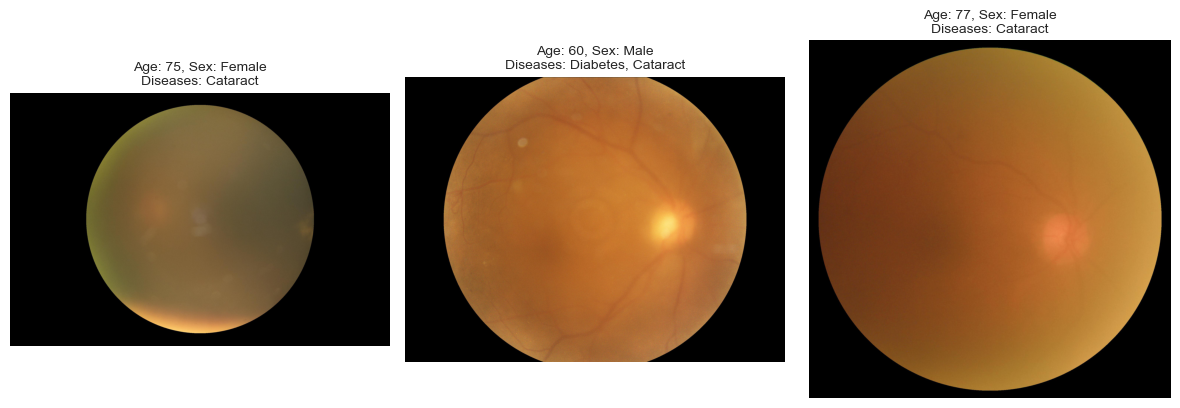


Age-related Macular Degeneration (A):


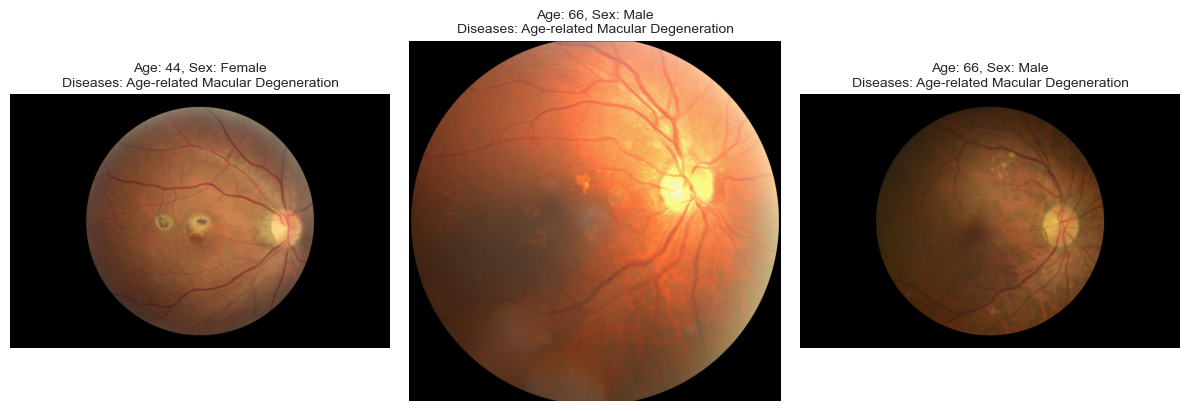


Pathological Myopia (M):


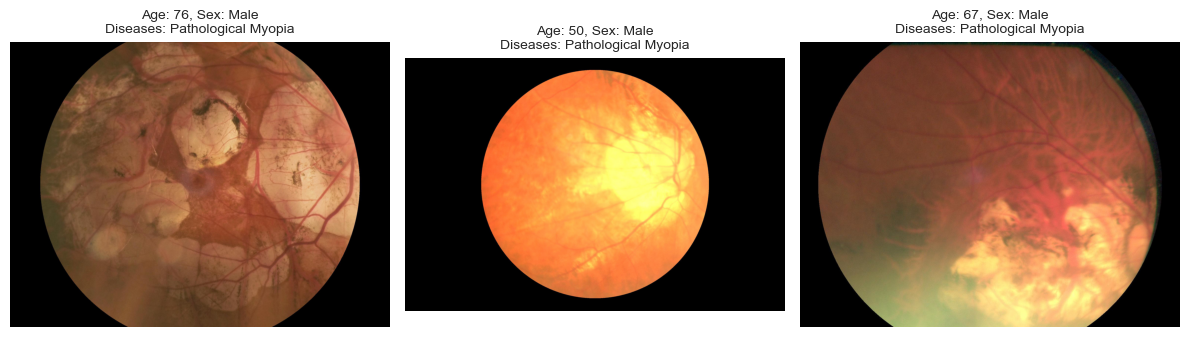


Other diseases/abnormalities (O):


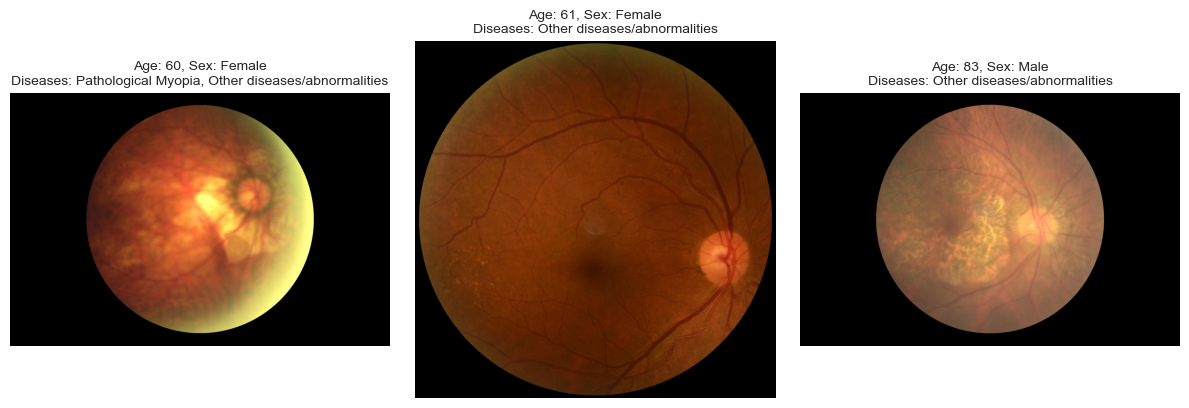

In [18]:
# Visualize samples for each disease category
print("Visualizing samples by disease category...\n")

for label in LABEL_COLUMNS:
    if label in df.columns:
        disease_df = df[df[label] == 1]
        if len(disease_df) > 0:
            print(f"\n{DISEASE_LABELS[label]} ({label}):")
            visualize_samples(disease_df, n_samples=3, image_column='Right-Fundus', show_labels=True)

## 9. Data Quality Checks

In [19]:
# Check for missing values
print("Missing values by column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

Missing values by column:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


In [20]:
# Check for duplicate records
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check ID uniqueness
if 'ID' in df.columns:
    print(f"Unique IDs: {df['ID'].nunique()}")
    print(f"Total rows: {len(df)}")


Duplicate rows: 0
Unique IDs: 3500
Total rows: 3500


## 10. Summary and Insights

In [21]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"\nTotal patients: {len(df)}")
print(f"\nDisease distribution:")
for _, row in disease_stats.iterrows():
    print(f"  {row['Disease Code']} ({row['Disease Name']}): {row['Count']} ({row['Percentage']})")

print(f"\nMulti-label statistics:")
print(f"  Single disease: {multilabel_analysis['single_disease']} patients")
print(f"  Multiple diseases: {multilabel_analysis['multiple_diseases']} patients")
print(f"  Average diseases per patient: {multilabel_analysis['avg_diseases_per_patient']:.2f}")

if 'Patient Age' in df.columns:
    print(f"\nAge statistics:")
    print(f"  Mean: {df['Patient Age'].mean():.1f} years")
    print(f"  Median: {df['Patient Age'].median():.1f} years")
    print(f"  Range: {df['Patient Age'].min():.0f} - {df['Patient Age'].max():.0f} years")

if 'Patient Sex' in df.columns:
    print(f"\nGender distribution:")
    for gender, count in df['Patient Sex'].value_counts().items():
        pct = (count / len(df)) * 100
        print(f"  {gender}: {count} ({pct:.1f}%)")

print("\n" + "="*60)

DATASET SUMMARY

Total patients: 3500

Disease distribution:
  N (Normal): 1140 (32.57%)
  D (Diabetes): 1128 (32.23%)
  G (Glaucoma): 215 (6.14%)
  C (Cataract): 212 (6.06%)
  A (Age-related Macular Degeneration): 164 (4.69%)
  M (Pathological Myopia): 174 (4.97%)
  O (Other diseases/abnormalities): 979 (27.97%)

Multi-label statistics:
  Single disease: 2941 patients
  Multiple diseases: 523 patients
  Average diseases per patient: 1.15

Age statistics:
  Mean: 57.9 years
  Median: 59.0 years
  Range: 1 - 91 years

Gender distribution:
  Male: 1885 (53.9%)
  Female: 1615 (46.1%)



## Next Steps

1. **Data Preprocessing**: Resize images, normalize pixel values, augment data
2. **Train/Validation/Test Split**: Split dataset for model training
3. **Model Development**: Build CNN or transfer learning model for multi-label classification
4. **Evaluation**: Use appropriate metrics (AUC-ROC, F1-score, precision, recall)
5. **Interpretability**: Use GradCAM or similar techniques to visualize model predictions